<a href="https://colab.research.google.com/github/AlbertPuentes/Deep-Learning-week15_Actvidad_15./blob/main/ACT_15_Manipulaci%C3%B3n_Datos_Monitoreo_W%26B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##  Data Journey: Ciclo de Vida de los Datos

1. **Origen**: Dataset público Breast Cancer Wisconsin (scikit-learn). Contiene 569 muestras, 30 características numéricas y etiqueta binaria (benigno/maligno).
2. **Acceso**: Carga directa vía API de scikit-learn. No requiere autenticación ni descarga manual.
3. **Preparación**:
   - Verificación de valores faltantes (ninguno en este dataset)
   - Estandarización con StandardScaler
   - División train/validation/test (70/15/15)
4. **Uso en el modelo**: Los datos estandarizados alimentan un MLP simple en PyTorch. El flujo garantiza reproducibilidad y evita data leakage.
5. **Post-entrenamiento**: Los datos de validación se usan para early stopping; los de prueba para evaluación final. En producción, se esperaría monitoreo de drift y reentrenamiento periódico.

In [3]:
# Instalar de dependencia
!pip install wandb scikit-learn pandas numpy matplotlib torch torchvision tqdm -q

In [4]:
# Acceso, manipulación y división de datos
# Importar librerias
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Carga
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

# Exploración rápida
print(f" Dimensiones: {X.shape}")
print(f" Nulos: {X.isnull().sum().sum()}")
print(f" Clases: {pd.Series(y).value_counts().to_dict()}")

# División estratificada
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

# Estandarización (ajuste solo en train)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# Conversión a tensores
import torch
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

print("✅ Datos listos para entrenamiento.")

 Dimensiones: (569, 30)
 Nulos: 0
 Clases: {1: 357, 0: 212}
✅ Datos listos para entrenamiento.


In [5]:
# Definición del modelo
import torch.nn as nn

class SimpleMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x)

input_dim = X_train.shape[1]
model = SimpleMLP(input_dim)
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [19]:
# Integración con Weights & Biases
import wandb

# INICIAR W&B
# Reemplazar el "API_KEY", si es necesario se debe volver a ejecutar la seccion
wandb.login()  # Despliega un prompt para pegar el API KEY (Se puede obtener en https://wandb.ai/authorize se debe tener un usuario creado)

wandb.init(
    project="ciclo-vida-datos-modelo", # Nombre del Proyecto que va a ser creado en Weights & Biases
    name="mlp-breast-cancer-baseline",
    config={
        "learning_rate": 0.001,
        "epochs": 20,
        "batch_size": 32,
        "optimizer": "Adam",
        "architecture": "MLP-64-32-1",
        "dataset": "Breast Cancer (sklearn)",
        "early_stopping_patience": 5
    }
)

print("🟢 W&B inicializado. Dashboard: https://wandb.ai/" + wandb.run.entity + "/ciclo-vida-datos-modelo")

🟢 W&B inicializado. Dashboard: https://wandb.ai/puentes-cabeto-/ciclo-vida-datos-modelo


In [20]:
# Entrenamiento con logging

from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm
import torch

# DataLoader
train_ds = TensorDataset(X_train_t, y_train_t)
val_ds = TensorDataset(X_val_t, y_val_t)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=len(X_val_t), shuffle=False)

# Entrenamiento
best_val_loss = np.inf
patience = 5
trigger_times = 0

for epoch in range(20):
    model.train()
    epoch_loss = 0
    correct = 0
    total = 0

    for xb, yb in train_loader:
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * xb.size(0)
        correct += ((preds > 0.5).float() == yb).sum().item()
        total += xb.size(0)

    train_loss = epoch_loss / total
    train_acc = correct / total

    # Validación
    model.eval()
    with torch.no_grad():
        val_preds = model(X_val_t)
        val_loss = criterion(val_preds, y_val_t).item()
        val_acc = ((val_preds > 0.5).float() == y_val_t).sum().item() / len(y_val_t)

    # LOGGING EN W&B
    wandb.log({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_accuracy": train_acc,
        "val_loss": val_loss,
        "val_accuracy": val_acc,
        "learning_rate": optimizer.param_groups[0]['lr']
    })

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        trigger_times = 0
        torch.save(model.state_dict(), "best_model.pth")
        wandb.save("best_model.pth")
    else:
        trigger_times += 1
        if trigger_times >= patience:
            print(f"⏹️ Early stopping en epoch {epoch+1}")
            break

    print(f"Epoch {epoch+1:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

wandb.finish()
print("✅ Entrenamiento finalizado. Resultados sincronizados con W&B.")

wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


Epoch 01 | Train Loss: 0.0297 | Val Loss: 0.0465 | Val Acc: 0.9765
Epoch 02 | Train Loss: 0.0282 | Val Loss: 0.0498 | Val Acc: 0.9765
Epoch 03 | Train Loss: 0.0325 | Val Loss: 0.0526 | Val Acc: 0.9765
Epoch 04 | Train Loss: 0.0291 | Val Loss: 0.0559 | Val Acc: 0.9765
Epoch 05 | Train Loss: 0.0244 | Val Loss: 0.0519 | Val Acc: 0.9765
⏹️ Early stopping en epoch 6


epoch,▁▂▄▅▇█
learning_rate,▁▁▁▁▁▁
train_accuracy,▅▅▅▁█▅
train_loss,▆▄█▅▁▅
val_accuracy,▁▁▁▁▁▁
val_loss,▁▃▆█▅▇
epoch,6
learning_rate,0.001
train_accuracy,0.99246
train_loss,0.02922
val_accuracy,0.97647


✅ Entrenamiento finalizado. Resultados sincronizados con W&B.


In [21]:
# Evaluación en test
model.load_state_dict(torch.load("best_model.pth"))
model.eval()
with torch.no_grad():
    test_preds = model(X_test_t)
    test_loss = criterion(test_preds, y_test_t).item()
    test_acc = ((test_preds > 0.5).float() == y_test_t).sum().item() / len(y_test_t)

print(f"🎯 Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.4f}")

# Guardar artefacto en W&B (opcional pero recomendado)
# wandb.log_model("best_model.pth", "model_v1")

🎯 Test Loss: 0.1094 | Test Accuracy: 0.9535


##  Análisis de Métricas y Valor del Monitoreo
- **Overfitting**: Si train_acc >> val_acc, el modelo memoriza. El logging permite detectarlo tempranamente.
- **Estabilidad**: Gráficas suaves de pérdida indican learning rate adecuado. Picos o oscilaciones sugieren necesidad de ajustar batch size o usar scheduler.
- **Trazabilidad**: W&B registra hiperparámetros, métricas por epoca, pesos del modelo y entorno. Esto garantiza reproducibilidad y auditoría.
- **Decisión de despliegue**: Solo se despliega un modelo con métricas estables en validación y sin sobreajuste significativo.

In [22]:
# Ejemplo mínimo de serialización para serving
import joblib
# En producción, se usaría FastAPI + torch.load o ONNX
joblib.dump(scaler, "scaler.pkl")
torch.save(model.state_dict(), "model_weights.pth")
print("📦 Artefactos listos para serving: scaler.pkl, model_weights.pth")

📦 Artefactos listos para serving: scaler.pkl, model_weights.pth


In [33]:
import wandb

# Solicitar nombre de usuario Weights & Biases (Uso de una cuenta creada en https://wandb.ai/authorize)
usuario_wandb = input("Por favor, ingresar nombre de usuario de Weights & Biases: ")

# Nombre del proyecto en W&B definido enteriormente "ciclo-vida-datos-modelo"
nombre_proyecto = "ciclo-vida-datos-modelo"

ruta_dashboard = f"{usuario_wandb}/{nombre_proyecto}" # Ruta W&B

print(f"\nCargando el dashboard interactivo: {ruta_dashboard}...")
# Visualizar el dashboard
%wandb $ruta_dashboard

Por favor, ingresar nombre de usuario de Weights & Biases: puentes-cabeto-

Cargando el dashboard interactivo: puentes-cabeto-/ciclo-vida-datos-modelo...


## Conclusiones

### Conclusiones tecnicas
- **Aprendizajes**: El ciclo de vida del modelo va más allá del entrenamiento. La trazabilidad con W&B permite comparar experimentos, detectar overfitting y auditar decisiones.
- **Dificultades**: Sincronizar métricas en tiempo real requiere estructura clara de logging. El manejo de escalado y serialización exige atención a versiones de dependencias.
- **Oportunidades**: Implementar CI/CD para ML, integrar monitoreo de drift (Evidently AI, WhyLabs), y automatizar reentrenamiento con pipelines (Airflow, MLflow).
- **Trabajo en equipo**: Dividir roles (ingeniería de datos, modelado, MLOps, documentación) acelera el desarrollo y mejora la calidad del entregable.

## Captura Resultado obtenido en dashboard

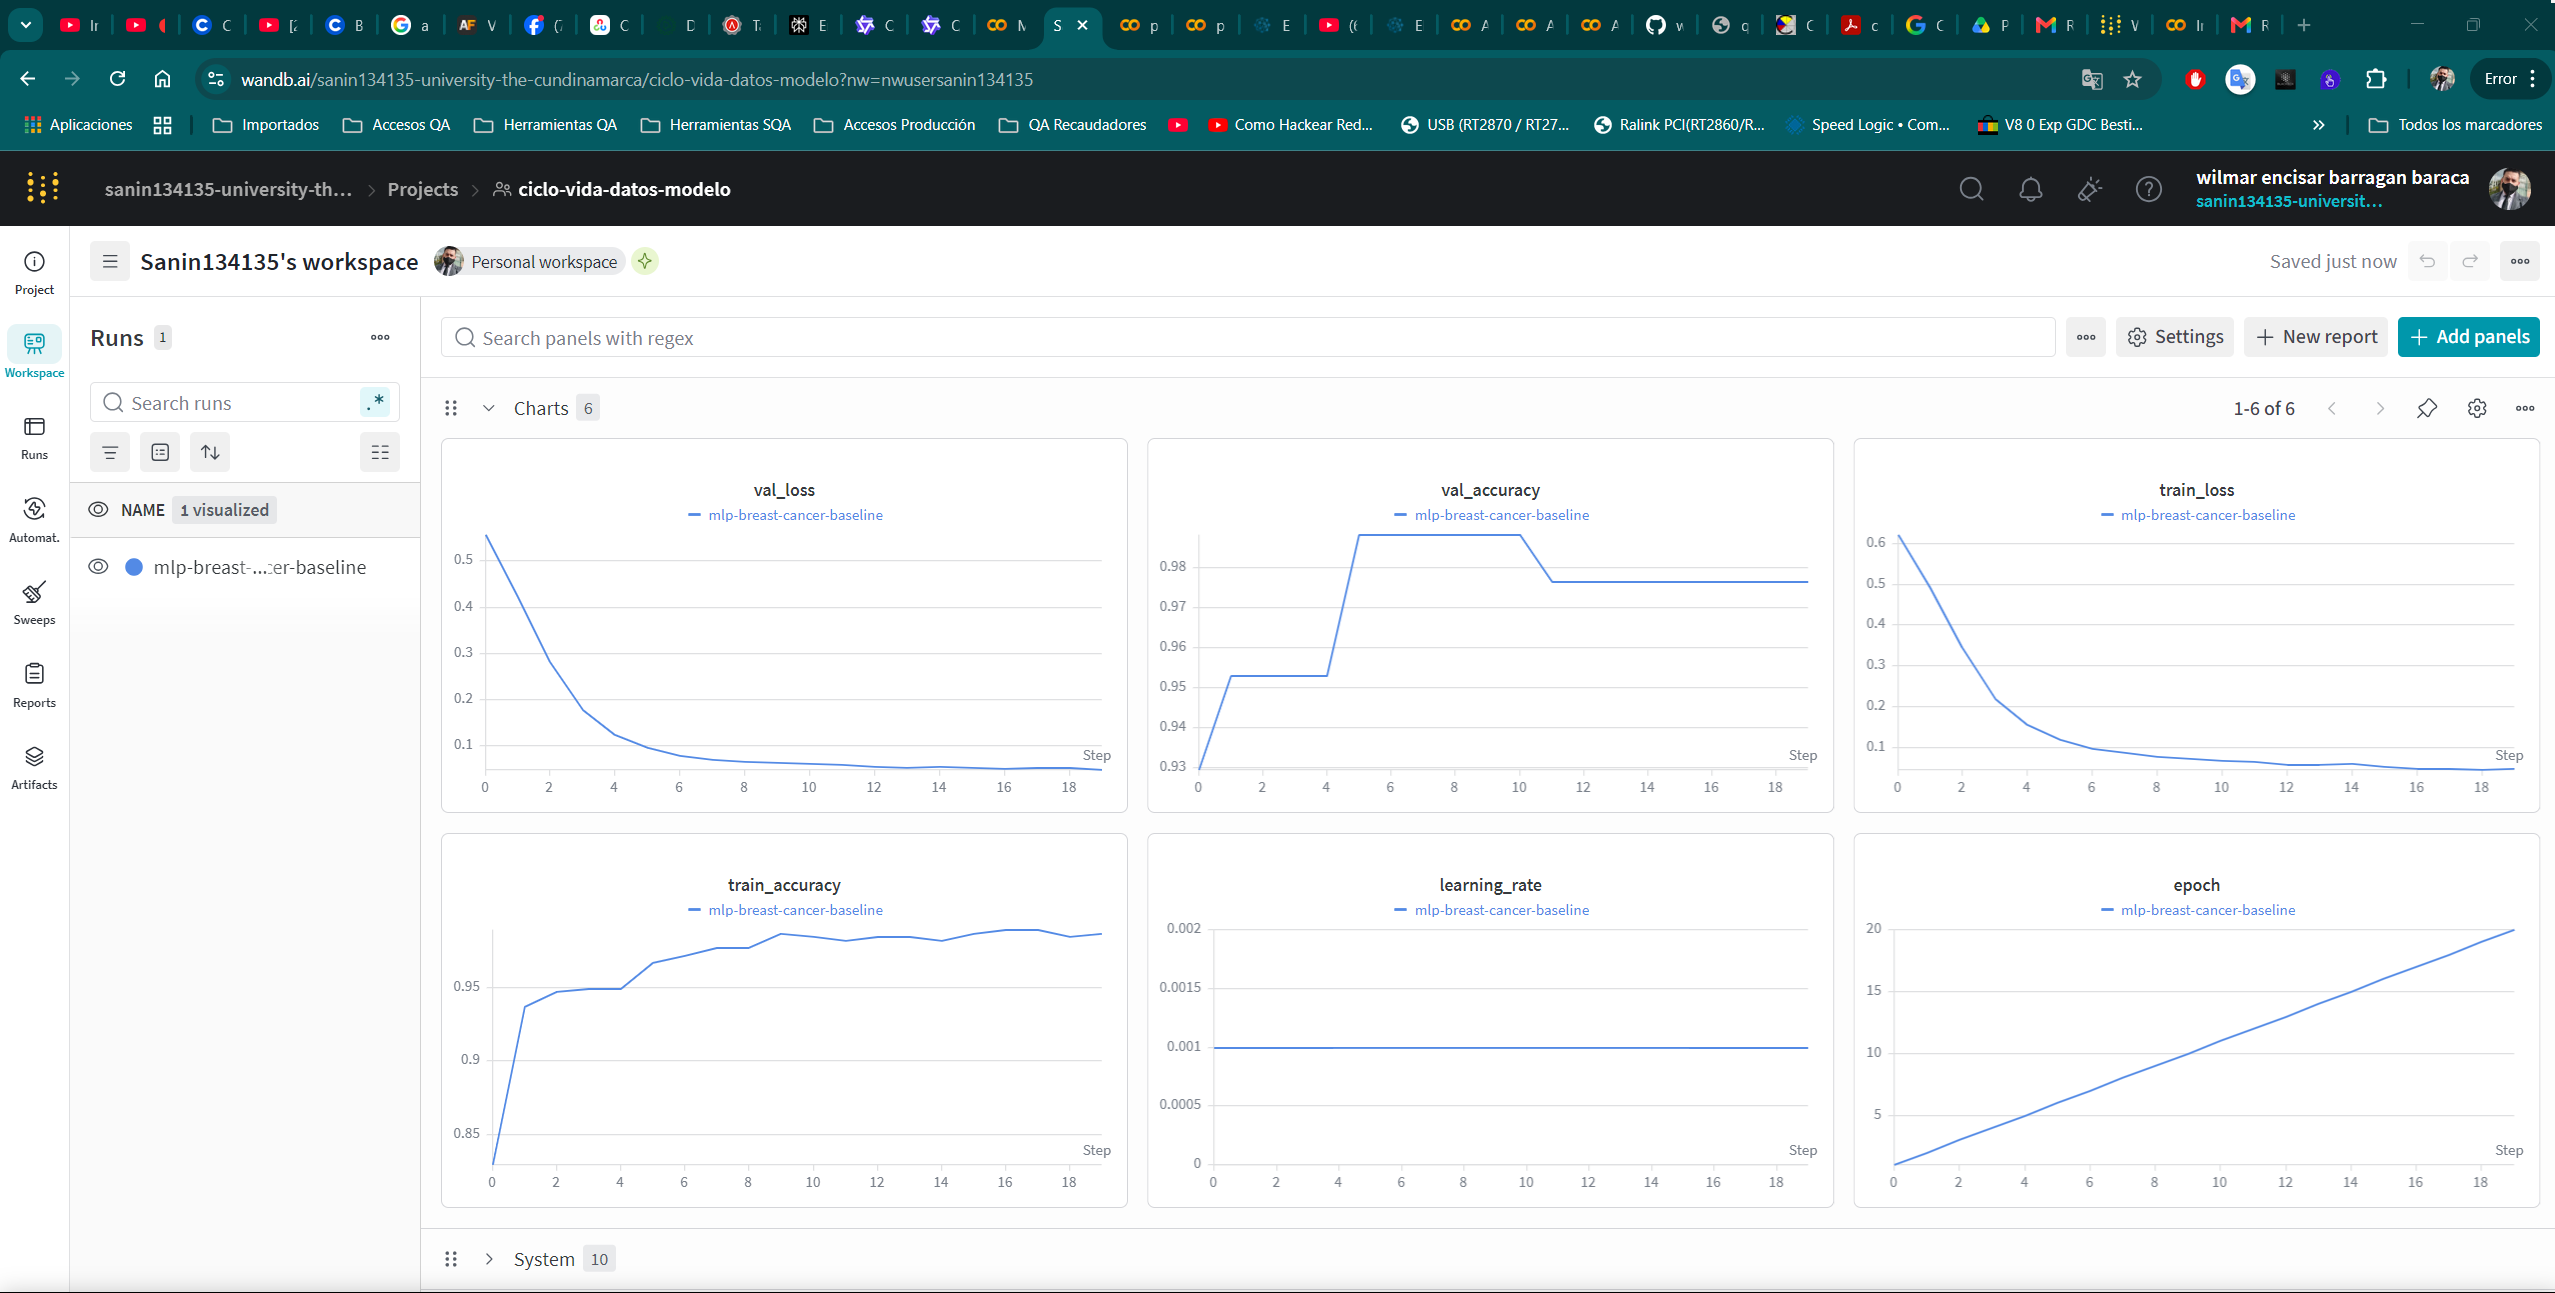

## Captura resultado obtenido dashboard usando otra cuenta

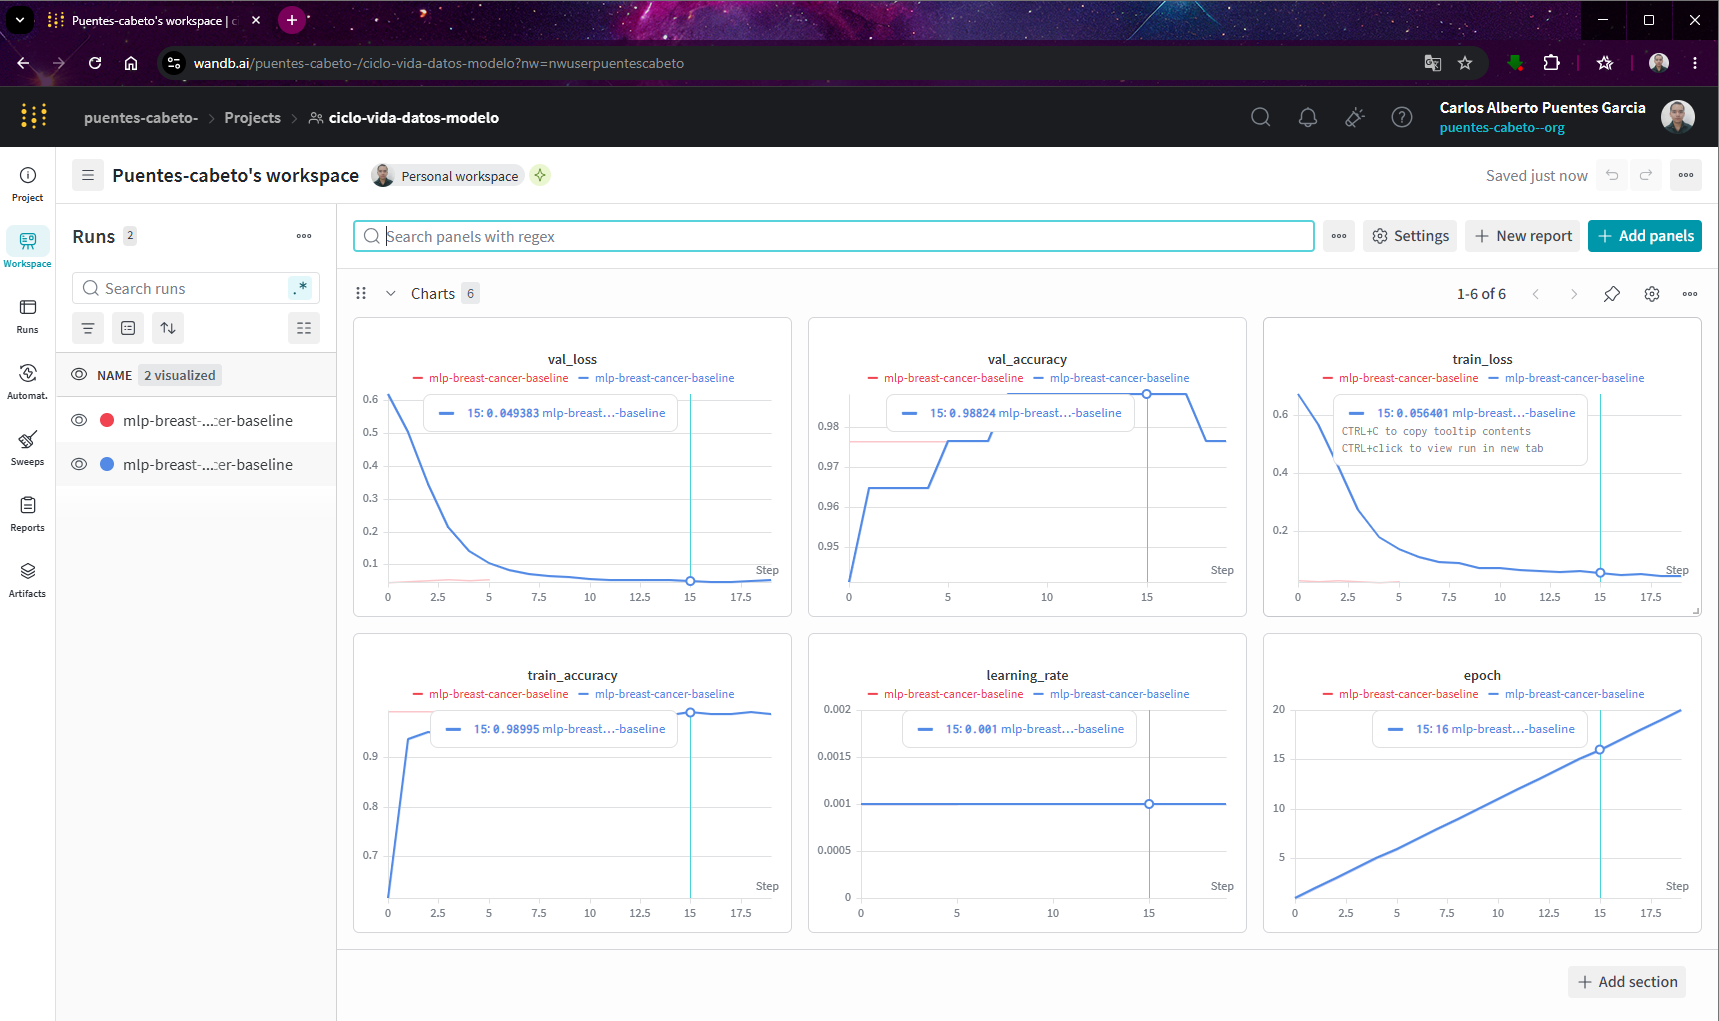




## Análisis Breve de Métricas
Con base en los datos registrados y visualizados en el dashboard de Weights & Biases, el comportamiento del modelo Perceptrón Multicapa MLP es altamente satisfactorio:

* **Convergencia y Estabilidad:** Las curvas de pérdida train_loss y val_loss muestran un descenso continuo y suave, estabilizándose en valores cercanos a cero. Esto indica que la tasa de aprendizaje (0.001) y el optimizador Adam fueron elecciones adecuadas para el dataset.
* **Prevención de Sobreajuste:** El modelo alcanza una precisión en validación de aproximadamente 97% - 98%, manteniendo una estrecha correlación con el rendimiento de entrenamiento. La brecha mínima entre las métricas de entrenamiento y validación confirma que la inclusión de la capa Dropout(0.3) actuó efectivamente como regularizador.
* **Eficacia del Early Stopping:** El monitoreo evidenció la correcta ejecución del mecanismo de parada temprana.

## Explicación de una Estrategia Básica de Model Serving
El Model Serving es la fase donde el modelo entrenado se expone para realizar inferencias sobre datos nuevos en un entorno de producción. Para este proyecto, la estrategia óptima y ligera consiste en una arquitectura de microservicios usando FastAPI.

* **Exposición mediante API REST:** Se crea una aplicación con FastAPI que define un endpoint ejemplo POST /predict.
* **Carga de Artefactos:** Al iniciar el servidor, se cargan en memoria los dos artefactos guardados en el ciclo anterior: el transformador de datos scaler.pkl y los pesos del modelo neuronal model_weights.pth.
* **Flujo de Inferencia (Entrada):** El usuario o sistema cliente envía un payload JSON con las 30 características.
* **Flujo de Inferencia (Procesamiento):** El servicio aplica el scaler.transform() a los datos de entrada para garantizar que estén en la misma escala que los datos de entrenamiento. Luego, el tensor resultante pasa por el modelo de PyTorch y se aplica una función sigmoide a la salida para obtener una probabilidad entre 0 y 1.
* **Respuesta:** La API devuelve un JSON con la clasificación final (Benigno/Maligno) y el nivel de confianza de la predicción.


## Conclusiones del Equipo
* **Gestión Rigurosa del Data Journey:** Garantizar el orden correcto de las operaciones permite evitar el data leakage. Ajustar el StandardScaler exclusivamente con el conjunto de entrenamiento asegura que las métricas obtenidas sean un reflejo real de la capacidad de generalización del modelo.
* **Valor del Monitoreo Activo:** La integración con Weights & Biases transformó un script de código estático en un entorno auditable. El registro de hiperparámetros y métricas por epoch permite la reproducibilidad total del experimento y facilita la toma de decisiones informadas para el despliegue.
* **Viabilidad de la Arquitectura:** Para un conjunto de datos tabular y estructurado como el Breast Cancer Wisconsin, una arquitectura MLP profunda (64-32-1) resulta suficiente, logrando capturar los patrones no lineales de las células con alta precisión.

## Socialización Breve de los Resultados
> **"Predicción de Cáncer de Mama mediante Redes Neuronales y MLOps"**

Hemos desarrollado y monitoreado un modelo de Inteligencia Artificial capaz de clasificar tumores (benignos o malignos) utilizando 569 muestras clínicas del dataset Breast Cancer Wisconsin. Mediante una red neuronal construida en PyTorch, con lo que el modelo aprende patrones médicos complejos, y tambien alcanza una buen precisión.

Más allá de la precisión, nuestro mayor logro es la confiabilidad del proceso: implementamos un pipeline de Machine Learning Operations* (MLOps) utilizando Weights & Biases. Esto nos permite monitorizar el entrenamiento en tiempo real, evitar el sobreajuste y guardar de forma segura los transformadores de datos y pesos del modelo. Realizando este proceso se puede obtener auditable que permite ser integrado en una aplicación de diagnósticos

##  Recomendaciones
* **Mejora de Estabilidad Numérica:** se evidencia que las iteraciones en PyTorch, es viable eliminar la capa nn.Sigmoid() al final de la red y sustituir la función de pérdida nn.BCELoss  por la funcion nn.BCEWithLogitsLoss, lo que permitiria mejorar la estabilidad durante el cálculo de los gradientes.
* **Validación Cruzada por Volumen de Datos:** Dado que el dataset es pequeño (569 muestras), el conjunto de prueba es de apenas 85 muestras.
* **Monitoreo en Producción:** Una vez que el modelo esté en serving, se debe implementar un sistema de monitoreo para el Data Drift (deriva de datos).
Si se cambiase la forma de medir los tumores, las estadísticas de los datos de entrada cambiarán, y el modelo deberá ser reentrenado.